In [ ]:
!pip install spacy scikit-learn nltk pandas numpy matplotlib seaborn wordcloud
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 42.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nlp = spacy.load("en_core_web_md")
print("✅ All libraries loaded successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


✅ All libraries loaded successfully!


In [ ]:

import zipfile
import os
import pandas as pd
from google.colab import files
print("📂 Please upload your Kaggle .zip file now...")
uploaded = files.upload()
zip_filename = [f for f in uploaded.keys() if f.endswith('.zip')]
if not zip_filename:
    print("❌ No zip file found! Make sure you uploaded a .zip file.")
else:
    zip_filename = zip_filename[0]
    print(f"✅ Found zip: {zip_filename}")
    extract_dir = "/content/kaggle_data"
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_filename, 'r') as z:
        z.extractall(extract_dir)
        print(f"✅ Extracted to: {extract_dir}")
        print(f"📁 Files inside:")
        for f in z.namelist():
            print(f"   → {f}")
    csv_files = []
    for root, dirs, files_list in os.walk(extract_dir):
        for file in files_list:
            if file.endswith('.csv'):
                csv_files.append(os.path.join(root, file))
    if not csv_files:
        print("❌ No CSV found inside the zip!")
    else:
        print(f"\n📊 CSV files found: {csv_files}")
        csv_path = csv_files[0]
        df_raw = pd.read_csv(csv_path)
        print(f"\n✅ Loaded CSV: {csv_path}")
        print(f"   Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
        print(f"   Columns: {list(df_raw.columns)}")
        print("\n🔍 First 2 rows:")
        print(df_raw.head(2))

📂 Please upload your Kaggle .zip file now...


Saving archive (2).zip to archive (2) (1).zip
✅ Found zip: archive (2) (1).zip
✅ Extracted to: /content/kaggle_data
📁 Files inside:
   → monster_com-job_sample.csv

📊 CSV files found: ['/content/kaggle_data/monster_com-job_sample.csv']

✅ Loaded CSV: /content/kaggle_data/monster_com-job_sample.csv
   Shape: 22000 rows × 14 columns
   Columns: ['country', 'country_code', 'date_added', 'has_expired', 'job_board', 'job_description', 'job_title', 'job_type', 'location', 'organization', 'page_url', 'salary', 'sector', 'uniq_id']

🔍 First 2 rows:
                    country country_code date_added has_expired  \
0  United States of America           US        NaN          No   
1  United States of America           US        NaN          No   

          job_board                                    job_description  \
0  jobs.monster.com  TeamSoft is seeing an IT Support Specialist to...   
1  jobs.monster.com  The Wisconsin State Journal is seeking a flexi...   

                            

In [ ]:
import pandas as pd
df = pd.read_csv('/content/kaggle_data/monster_com-job_sample.csv')
print("📊 Available Sectors:")
print(df['sector'].value_counts().head(15))
print()
TARGET_SECTOR = "IT/Software Development"
df_sector = df[df['sector'] == TARGET_SECTOR].dropna(subset=['job_description'])
print(f"✅ Found {len(df_sector)} job postings in: {TARGET_SECTOR}")
print()
sample_jd = df_sector.iloc[0]
job_description = sample_jd['job_description']
job_title_label = sample_jd['job_title']
print(f"🎯 Target Job Title : {job_title_label}")
print(f"📋 Job Description Preview:\n")
print(job_description[:500])
print("...")

📊 Available Sectors:
sector
Experienced (Non-Manager)                4594
Medical/Health                           1254
Entry Level                              1172
Sales/Retail/Business Development         938
Manager (Manager/Supervisor of Staff)     900
IT/Software Development                   861
Project/Program Management                790
Accounting/Finance/Insurance              742
Food Services/Hospitality                 633
Installation/Maintenance/Repair           574
Manufacturing/Production/Operations       544
Logistics/Transportation                  371
Customer Support/Client Care              328
Quality Assurance/Safety                  323
Security/Protective Services              311
Name: count, dtype: int64

✅ Found 861 job postings in: IT/Software Development

🎯 Target Job Title : IT Support Technician Job in Madison
📋 Job Description Preview:

TeamSoft is seeing an IT Support Specialist to join our client in Madison, WI. The ideal candidate must have at lea

In [ ]:
df_candidates = df_sector.iloc[1:21].reset_index(drop=True)  # up to 20 candidates

resumes = []
for i, row in df_candidates.iterrows():
    resumes.append({
        "name": f"Candidate_{i+1:02d}",
        "resume": str(row['job_description']),
        "job_title": str(row['job_title']),
        "organization": str(row.get('organization', 'Unknown')),
        "location": str(row.get('location', 'Unknown'))
    })

print(f"✅ Created {len(resumes)} candidate profiles from job postings")
print()
print("📄 Sample Candidate:")
print(f"  Name     : {resumes[0]['name']}")
print(f"  Title    : {resumes[0]['job_title']}")
print(f"  Location : {resumes[0]['location']}")
print(f"  Preview  : {resumes[0]['resume'][:200]}...")

✅ Created 20 candidate profiles from job postings

📄 Sample Candidate:
  Name     : Candidate_01
  Title    : Scrum Master Job in Denver
  Location : Denver, CO
  Preview  : The Judge Group is looking for a Scrum Master for our client in Denver. Please email Josh Freidus at Jfreidus@judge.com for more details.W2 Only - NO C2C or Third Parties5+ Years of experience as a sc...


In [ ]:

SKILL_DICT = {
    "programming": ["python", "java", "javascript", "c++", "r", "scala", "sql", "bash"],
    "ml_frameworks": ["scikit-learn", "sklearn", "tensorflow", "pytorch", "keras",
                       "xgboost", "lightgbm", "catboost"],
    "nlp": ["spacy", "nltk", "transformers", "bert", "gpt", "hugging face",
             "text classification", "ner", "named entity recognition"],
    "data_tools": ["pandas", "numpy", "matplotlib", "seaborn", "tableau",
                    "power bi", "excel", "spark", "pyspark", "hadoop"],
    "cloud_devops": ["aws", "gcp", "azure", "docker", "kubernetes", "flask",
                      "fastapi", "rest api", "ci/cd", "git", "mlflow"],
    "databases": ["sql", "mysql", "postgresql", "mongodb", "redis"],
    "soft_skills": ["communication", "agile", "teamwork", "leadership", "problem solving"],
    "education": ["msc", "phd", "bsc", "bachelor", "master", "research", "published"]
}


ALL_SKILLS = [skill for group in SKILL_DICT.values() for skill in group]
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Clean and normalize text."""
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-z0-9\s\+\#]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

def extract_skills(text):
    """Extract skills from text using the skill dictionary."""
    text_lower = text.lower()
    found_skills = []
    for skill in ALL_SKILLS:
        if skill in text_lower:
            found_skills.append(skill)
    return list(set(found_skills))
sample = preprocess_text(resumes[0]['resume'])
print("📝 Sample preprocessed text (first 200 chars):")
print(sample[:200])
print("\n🔧 Extracted skills:", extract_skills(resumes[0]['resume']))

📝 Sample preprocessed text (first 200 chars):
judge group looking scrum master client denver please email josh freidus jfreidus judge com detail w2 c2c third parties5+ year experience scrum master 8+ year experience project management proficient 

🔧 Extracted skills: ['r', 'java', 'master']


In [ ]:
for r in resumes:
    r['processed'] = preprocess_text(r['resume'])
    r['skills'] = extract_skills(r['resume'])

# Preprocess job description
jd_processed = preprocess_text(job_description)
jd_skills = extract_skills(job_description)

print("✅ All resumes preprocessed!")
print(f"\n📋 Job Description Skills ({len(jd_skills)}):")
print(", ".join(jd_skills))

✅ All resumes preprocessed!

📋 Job Description Skills (3):
r, communication, ner


In [ ]:
all_docs = [jd_processed] + [r['processed'] for r in resumes]
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
tfidf_matrix = tfidf.fit_transform(all_docs)
jd_vector = tfidf_matrix[0]
resume_vectors = tfidf_matrix[1:]
similarities = cosine_similarity(jd_vector, resume_vectors)[0]
for i, r in enumerate(resumes):
    r['tfidf_score'] = round(float(similarities[i]) * 100, 2)
print("✅ TF-IDF similarity scores computed!")
for r in resumes:
    print(f"  {r['name']:20s} → TF-IDF Score: {r['tfidf_score']:.1f}%")

✅ TF-IDF similarity scores computed!
  Candidate_01         → TF-IDF Score: 3.0%
  Candidate_02         → TF-IDF Score: 2.4%
  Candidate_03         → TF-IDF Score: 5.0%
  Candidate_04         → TF-IDF Score: 4.6%
  Candidate_05         → TF-IDF Score: 4.4%
  Candidate_06         → TF-IDF Score: 2.0%
  Candidate_07         → TF-IDF Score: 1.1%
  Candidate_08         → TF-IDF Score: 1.4%
  Candidate_09         → TF-IDF Score: 4.8%
  Candidate_10         → TF-IDF Score: 7.3%
  Candidate_11         → TF-IDF Score: 4.5%
  Candidate_12         → TF-IDF Score: 4.4%
  Candidate_13         → TF-IDF Score: 5.9%
  Candidate_14         → TF-IDF Score: 9.1%
  Candidate_15         → TF-IDF Score: 1.6%
  Candidate_16         → TF-IDF Score: 4.6%
  Candidate_17         → TF-IDF Score: 9.4%
  Candidate_18         → TF-IDF Score: 2.9%
  Candidate_19         → TF-IDF Score: 2.9%
  Candidate_20         → TF-IDF Score: 4.9%


In [ ]:
def skill_match_score(resume_skills, jd_skills):
    """Calculate what % of JD skills the resume covers."""
    if not jd_skills:
        return 0, [], []
    matched = [s for s in jd_skills if s in resume_skills]
    missing = [s for s in jd_skills if s not in resume_skills]
    score = round((len(matched) / len(jd_skills)) * 100, 2)
    return score, matched, missing

for r in resumes:
    score, matched, missing = skill_match_score(r['skills'], jd_skills)
    r['skill_score'] = score
    r['matched_skills'] = matched
    r['missing_skills'] = missing

print("✅ Skill match scores computed!\n")
for r in resumes:
    print(f"  {r['name']:20s} → Skill Match: {r['skill_score']:.1f}%  |  "
          f"Matched: {len(r['matched_skills'])}  |  Missing: {len(r['missing_skills'])}")

✅ Skill match scores computed!

  Candidate_01         → Skill Match: 33.3%  |  Matched: 1  |  Missing: 2
  Candidate_02         → Skill Match: 33.3%  |  Matched: 1  |  Missing: 2
  Candidate_03         → Skill Match: 66.7%  |  Matched: 2  |  Missing: 1
  Candidate_04         → Skill Match: 66.7%  |  Matched: 2  |  Missing: 1
  Candidate_05         → Skill Match: 100.0%  |  Matched: 3  |  Missing: 0
  Candidate_06         → Skill Match: 33.3%  |  Matched: 1  |  Missing: 2
  Candidate_07         → Skill Match: 33.3%  |  Matched: 1  |  Missing: 2
  Candidate_08         → Skill Match: 33.3%  |  Matched: 1  |  Missing: 2
  Candidate_09         → Skill Match: 100.0%  |  Matched: 3  |  Missing: 0
  Candidate_10         → Skill Match: 100.0%  |  Matched: 3  |  Missing: 0
  Candidate_11         → Skill Match: 33.3%  |  Matched: 1  |  Missing: 2
  Candidate_12         → Skill Match: 66.7%  |  Matched: 2  |  Missing: 1
  Candidate_13         → Skill Match: 100.0%  |  Matched: 3  |  Missing: 0
  

In [ ]:
TFIDF_WEIGHT = 0.4
SKILL_WEIGHT = 0.6

for r in resumes:
    r['final_score'] = round(
        (r['tfidf_score'] * TFIDF_WEIGHT) + (r['skill_score'] * SKILL_WEIGHT), 2
    )
ranked = sorted(resumes, key=lambda x: x['final_score'], reverse=True)
print("=" * 70)
print(f"{'RANK':<6} {'NAME':<22} {'TF-IDF':>8} {'SKILL%':>8} {'FINAL':>8}")
print("=" * 70)
for i, r in enumerate(ranked):
    medal = ["🥇", "🥈", "🥉"][i] if i < 3 else f"#{i+1}"
    print(f"{medal:<6} {r['name']:<22} {r['tfidf_score']:>7.1f}% {r['skill_score']:>7.1f}% {r['final_score']:>7.1f}%")
print("=" * 70)

RANK   NAME                     TF-IDF   SKILL%    FINAL
🥇      Candidate_10               7.3%   100.0%    62.9%
🥈      Candidate_13               5.9%   100.0%    62.4%
🥉      Candidate_09               4.8%   100.0%    61.9%
#4     Candidate_05               4.4%   100.0%    61.8%
#5     Candidate_18               2.9%   100.0%    61.1%
#6     Candidate_17               9.4%    66.7%    43.8%
#7     Candidate_14               9.1%    66.7%    43.7%
#8     Candidate_03               5.0%    66.7%    42.0%
#9     Candidate_20               4.9%    66.7%    42.0%
#10    Candidate_04               4.6%    66.7%    41.8%
#11    Candidate_12               4.4%    66.7%    41.8%
#12    Candidate_19               2.9%    66.7%    41.2%
#13    Candidate_16               4.6%    33.3%    21.8%
#14    Candidate_11               4.5%    33.3%    21.8%
#15    Candidate_01               3.0%    33.3%    21.2%
#16    Candidate_02               2.4%    33.3%    21.0%
#17    Candidate_06            

In [ ]:
print("\n" + "="*75)
print("     📄 ENHANCED REPORT — Monster.com Job Matching Results")
print("="*75)
print(f"🎯 Target Role : {job_title_label}")
print(f"📌 Sector      : {TARGET_SECTOR}")
print()
for i, r in enumerate(ranked):
    score = r['final_score']
    status = "🟢 Strong Match" if score >= 60 else "🟡 Partial Match" if score >= 35 else "🔴 Weak Match"
    print(f"{'─'*65}")
    print(f"Rank #{i+1}  |  {status}")
    print(f"  Profile  : {r.get('job_title', r['name'])}")
    print(f"  Location : {r.get('location', 'N/A')}")
    print(f"  Score    : {score:.1f}%  (TF-IDF: {r['tfidf_score']:.1f}% | Skills: {r['skill_score']:.1f}%)")
    print(f"  ✅ Has   : {', '.join(r['matched_skills'][:6]) or 'None detected'}")
    print(f"  ❌ Lacks : {', '.join(r['missing_skills'][:6]) or 'Fully matched!'}")
    print()


     📄 ENHANCED REPORT — Monster.com Job Matching Results
🎯 Target Role : IT Support Technician Job in Madison
📌 Sector      : IT/Software Development

─────────────────────────────────────────────────────────────────
Rank #1  |  🟢 Strong Match
  Profile  : Solutions Architect- Cloud Solutions Job in Dallas
  Location : Dallas, TX
  Score    : 62.9%  (TF-IDF: 7.3% | Skills: 100.0%)
  ✅ Has   : r, communication, ner
  ❌ Lacks : Fully matched!

─────────────────────────────────────────────────────────────────
Rank #2  |  🟢 Strong Match
  Profile  : Systems Administrator Job in Dallas
  Location : Systems Administrator
  Score    : 62.4%  (TF-IDF: 5.9% | Skills: 100.0%)
  ✅ Has   : r, communication, ner
  ❌ Lacks : Fully matched!

─────────────────────────────────────────────────────────────────
Rank #3  |  🟢 Strong Match
  Profile  : Recruiter Job in Coppell
  Location : Coppell, TX
  Score    : 61.9%  (TF-IDF: 4.8% | Skills: 100.0%)
  ✅ Has   : r, communication, ner
  ❌ Lacks : Fully m

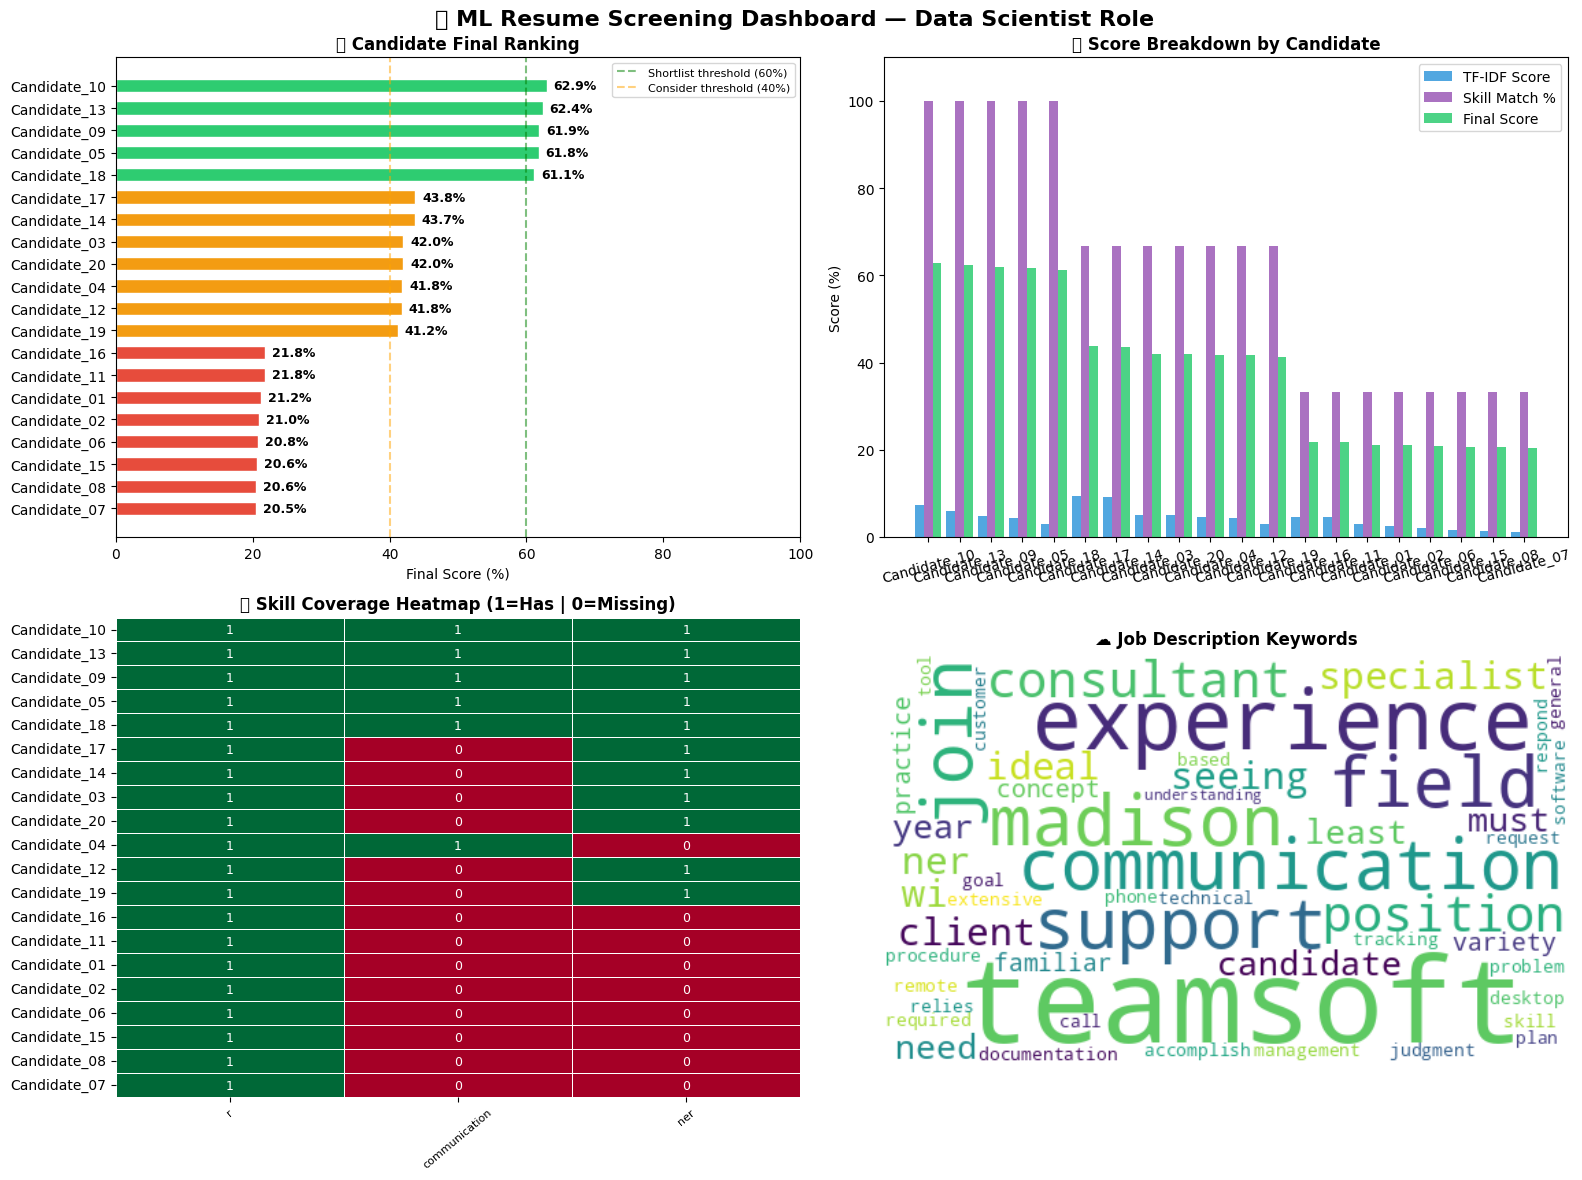

✅ Dashboard saved as 'resume_screening_dashboard.png'


In [ ]:
names = [r['name'].split()[0] for r in ranked]  # first names for brevity
final_scores = [r['final_score'] for r in ranked]
skill_scores = [r['skill_score'] for r in ranked]
tfidf_scores = [r['tfidf_score'] for r in ranked]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("📊 ML Resume Screening Dashboard — Data Scientist Role",
             fontsize=16, fontweight='bold', y=0.98)

ax1 = axes[0, 0]
colors = ['#2ecc71' if s >= 60 else '#f39c12' if s >= 40 else '#e74c3c' for s in final_scores]
bars = ax1.barh(names, final_scores, color=colors, edgecolor='white', height=0.6)
ax1.set_xlabel("Final Score (%)")
ax1.set_title("🏆 Candidate Final Ranking", fontweight='bold')
ax1.set_xlim(0, 100)
ax1.axvline(60, color='green', linestyle='--', alpha=0.5, label='Shortlist threshold (60%)')
ax1.axvline(40, color='orange', linestyle='--', alpha=0.5, label='Consider threshold (40%)')
ax1.legend(fontsize=8)
for bar, score in zip(bars, final_scores):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{score:.1f}%', va='center', fontsize=9, fontweight='bold')
ax1.invert_yaxis()

ax2 = axes[0, 1]
x = np.arange(len(names))
width = 0.28
ax2.bar(x - width, tfidf_scores, width, label='TF-IDF Score', color='#3498db', alpha=0.85)
ax2.bar(x, skill_scores, width, label='Skill Match %', color='#9b59b6', alpha=0.85)
ax2.bar(x + width, final_scores, width, label='Final Score', color='#2ecc71', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=15)
ax2.set_ylabel("Score (%)")
ax2.set_title("📊 Score Breakdown by Candidate", fontweight='bold')
ax2.legend()
ax2.set_ylim(0, 110)
ax3 = axes[1, 0]
skill_matrix = []
for r in ranked:
    row = [1 if s in r['skills'] else 0 for s in jd_skills]
    skill_matrix.append(row)

skill_df = pd.DataFrame(skill_matrix, columns=jd_skills, index=names)
sns.heatmap(skill_df, ax=ax3, cmap='RdYlGn', cbar=False,
            linewidths=0.5, linecolor='white',
            annot=True, fmt='d', annot_kws={'size': 9})
ax3.set_title("🔥 Skill Coverage Heatmap (1=Has | 0=Missing)", fontweight='bold')
ax3.set_xlabel("")
ax3.tick_params(axis='x', rotation=40, labelsize=8)
ax4 = axes[1, 1]
wordcloud_text = ' '.join(jd_skills + jd_processed.split()[:100])
wc = WordCloud(width=500, height=300, background_color='white',
               colormap='viridis', max_words=50).generate(wordcloud_text)
ax4.imshow(wc, interpolation='bilinear')
ax4.axis('off')
ax4.set_title("☁️ Job Description Keywords", fontweight='bold')

plt.tight_layout()
plt.savefig("resume_screening_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved as 'resume_screening_dashboard.png'")

Rank,Candidate,Final Score,TF-IDF,Skill Match,✅ Has,❌ Missing,Status
🥇,Solutions Architect- Cloud Solution,62.9%,7.3%,100.0%,"r, communication, ner",None ✅,Shortlisted
🥈,Systems Administrator Job in Dallas,62.4%,5.9%,100.0%,"r, communication, ner",None ✅,Shortlisted
🥉,Recruiter Job in Coppell,61.9%,4.8%,100.0%,"r, communication, ner",None ✅,Shortlisted
#4,Database Architect Job in Denver,61.8%,4.4%,100.0%,"r, communication, ner",None ✅,Shortlisted
#5,Senior Telecommunications Engineer,61.1%,2.9%,100.0%,"r, communication, ner",None ✅,Shortlisted
#6,Sr. Software Systems Engineer Job i,43.8%,9.4%,66.7%,"r, ner",communication,Consider
#7,Sr. .Net Developer Job in Dallas,43.7%,9.1%,66.7%,"r, ner",communication,Consider
#8,Principal Cyber Security Engineer J,42.0%,5.0%,66.7%,"r, ner",communication,Consider
#9,Firewall Engineer Job in Plano,42.0%,4.9%,66.7%,"r, ner",communication,Consider
#10,Business Analyst Job in Houston,41.8%,4.6%,66.7%,"r, communication",ner,Consider

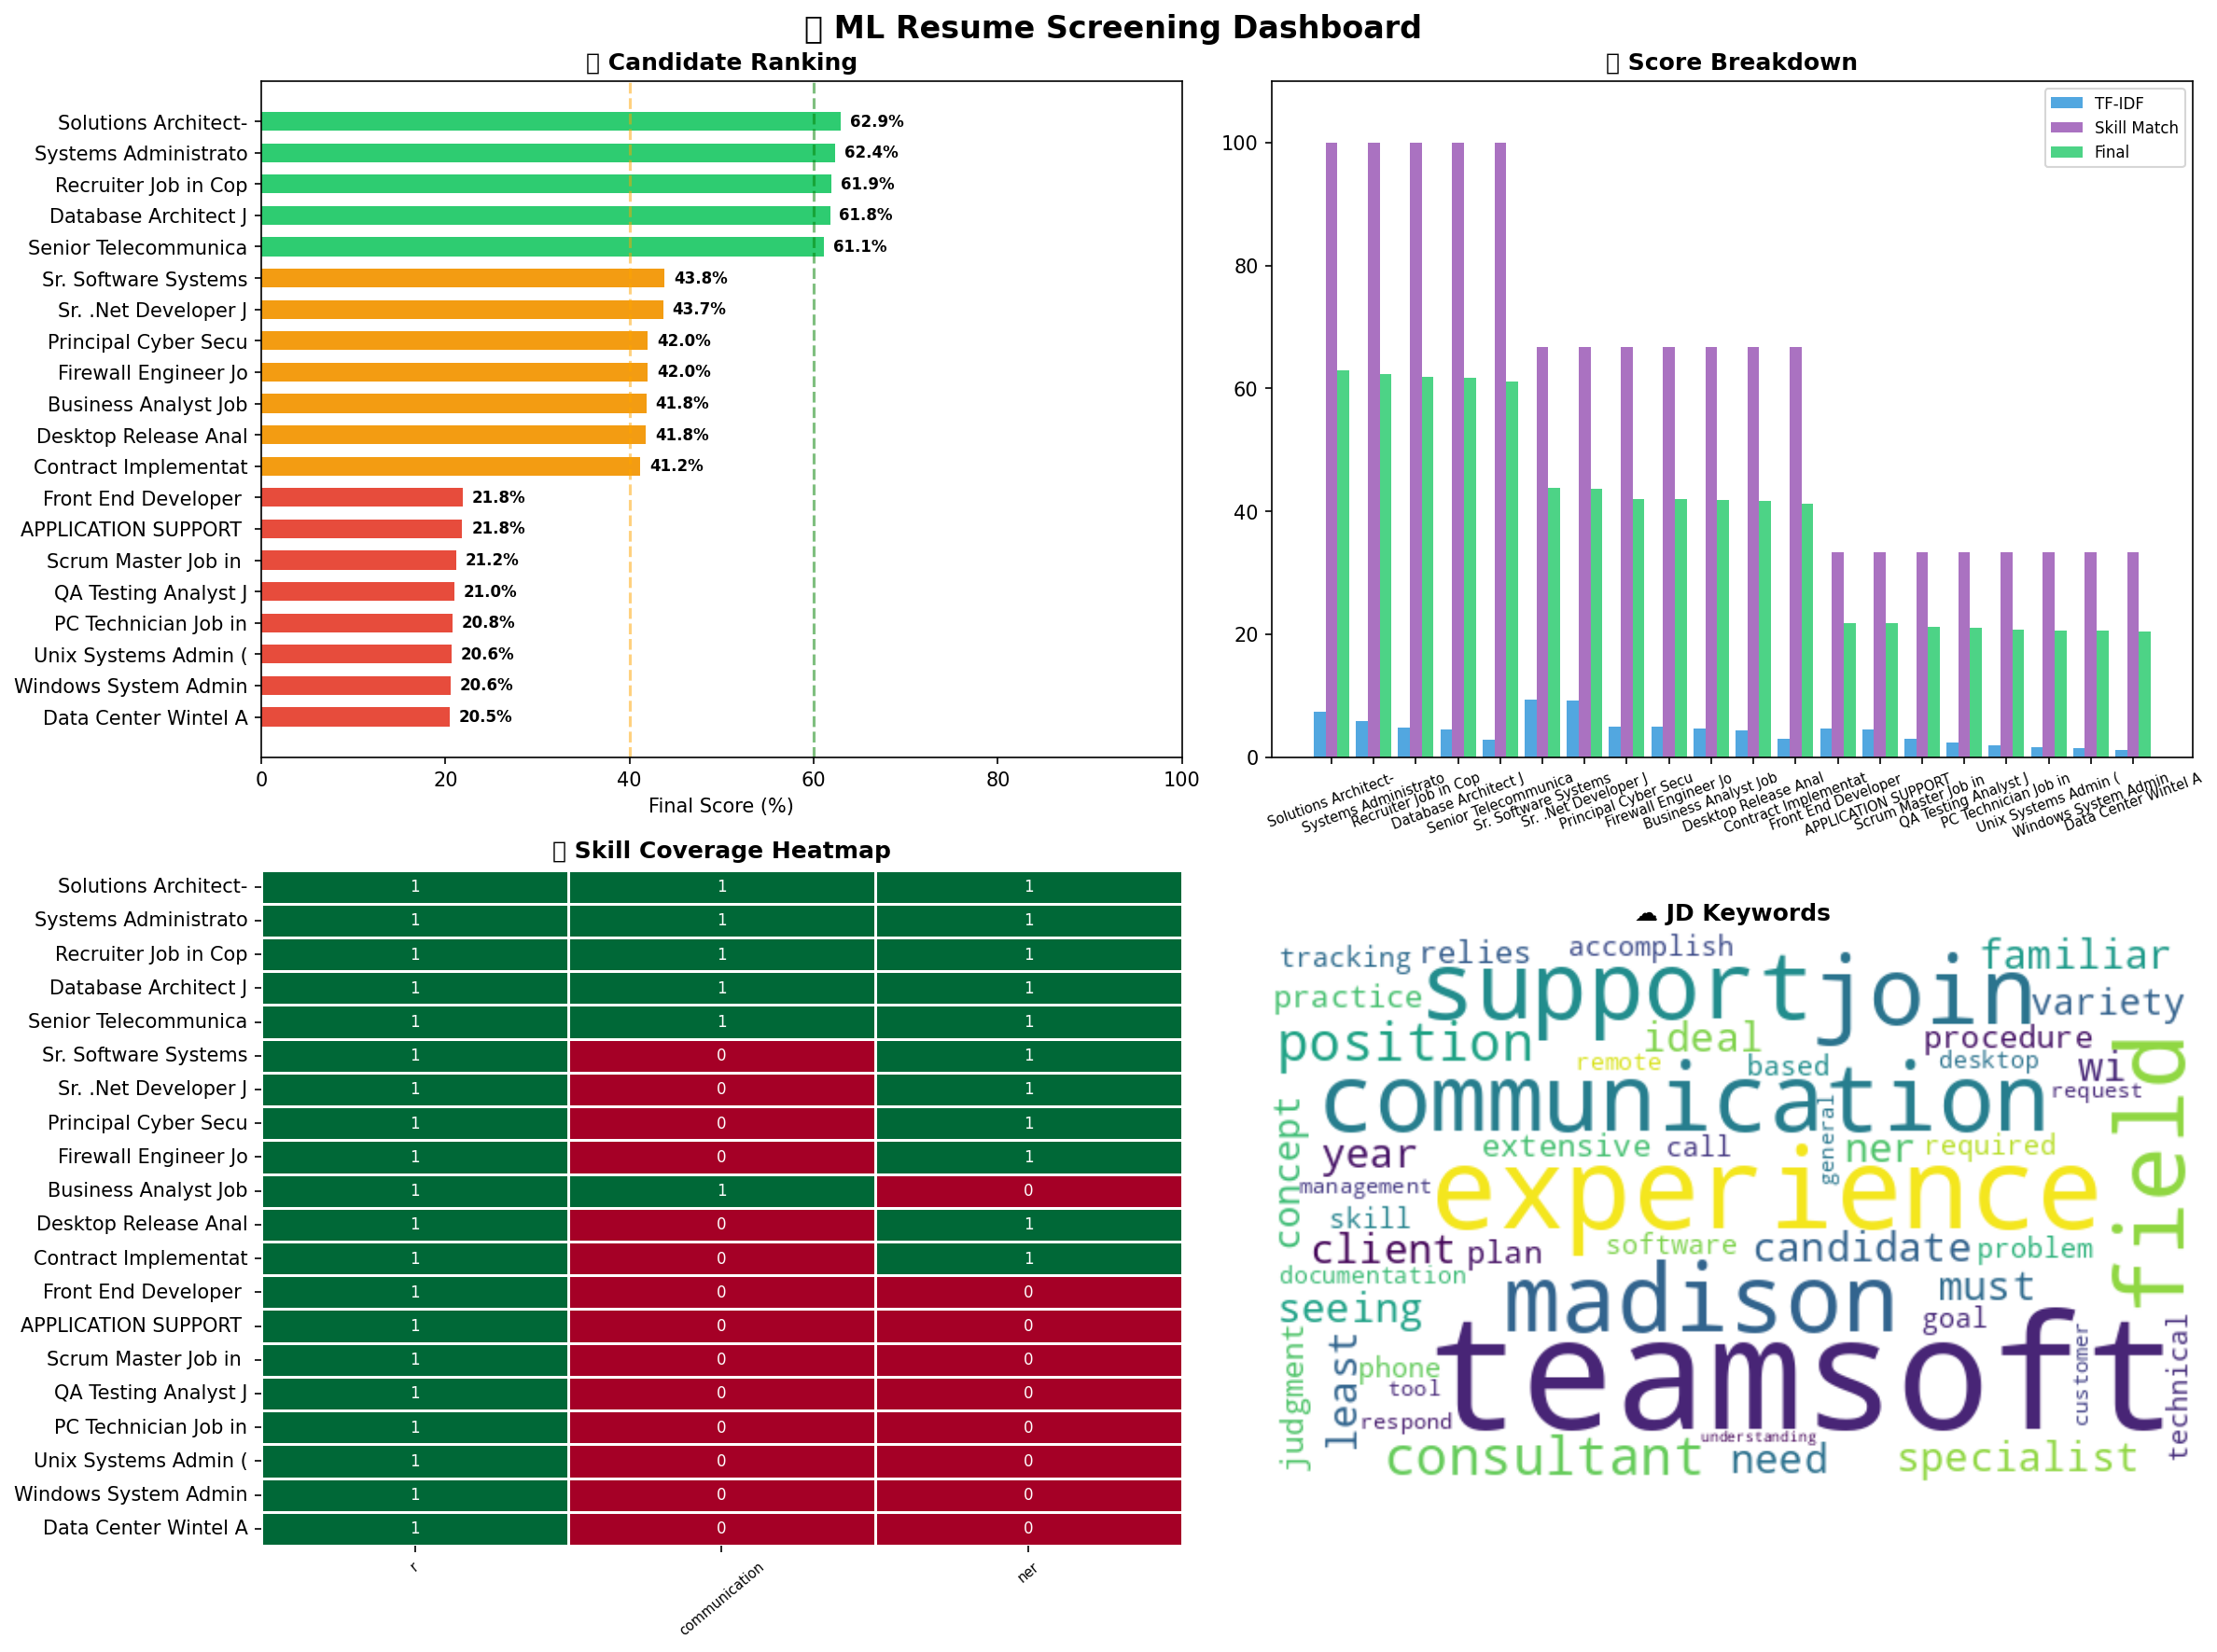

✅ Dashboard rendered above!


In [ ]:
import base64, io
from IPython.display import display, HTML
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)
img_base64 = base64.b64encode(buf.read()).decode('utf-8')
table_rows = ""
for i, r in enumerate(ranked):
    medal = ["🥇","🥈","🥉"][i] if i < 3 else f"#{i+1}"
    status_color = "#2ecc71" if r['final_score'] >= 60 else "#f39c12" if r['final_score'] >= 40 else "#e74c3c"
    status_text  = "Shortlisted" if r['final_score'] >= 60 else "Consider" if r['final_score'] >= 40 else "Rejected"
    matched = ', '.join(r['matched_skills'][:4]) or "—"
    missing = ', '.join(r['missing_skills'][:4]) or "None ✅"
    table_rows += f"""
    <tr>
      <td>{medal}</td>
      <td>{r.get('job_title', r['name'])[:35]}</td>
      <td><b>{r['final_score']:.1f}%</b></td>
      <td>{r['tfidf_score']:.1f}%</td>
      <td>{r['skill_score']:.1f}%</td>
      <td style='color:#2ecc71;font-size:12px'>{matched}</td>
      <td style='color:#e74c3c;font-size:12px'>{missing}</td>
      <td><span style='background:{status_color};padding:3px 10px;
          border-radius:20px;font-size:12px;font-weight:bold;
          color:white'>{status_text}</span></td>
    </tr>"""

dashboard_html = f"""
<div style="
    background: linear-gradient(135deg, #0f0c29, #302b63, #24243e);
    border-radius: 16px;
    padding: 30px;
    font-family: 'Segoe UI', sans-serif;
    color: white;
    margin: 10px 0;
">

  <!-- Header -->
  <div style="text-align:center; margin-bottom:25px;">
    <h1 style="color:#00d4aa; font-size:28px; margin:0;">
      📊 ML Resume Screening Dashboard
    </h1>
    <p style="color:#aaa; margin:8px 0 0 0;">
      🎯 Target Role: <b style="color:white">{job_title_label}</b>
      &nbsp;|&nbsp; Sector: <b style="color:white">{TARGET_SECTOR}</b>
      &nbsp;|&nbsp; Candidates: <b style="color:white">{len(ranked)}</b>
    </p>
  </div>

  <!-- Stats Row -->
  <div style="display:flex; gap:15px; margin-bottom:25px; flex-wrap:wrap;">
    {"".join([f'''
    <div style="flex:1; min-width:140px; background:rgba(255,255,255,0.07);
                border-radius:12px; padding:15px; text-align:center;
                border:1px solid rgba(255,255,255,0.1);">
      <div style="font-size:28px; font-weight:bold; color:#00d4aa;">
        {sum(1 for r in ranked if r["final_score"] >= 60)}
      </div>
      <div style="color:#aaa; font-size:13px;">✅ Shortlisted</div>
    </div>
    <div style="flex:1; min-width:140px; background:rgba(255,255,255,0.07);
                border-radius:12px; padding:15px; text-align:center;
                border:1px solid rgba(255,255,255,0.1);">
      <div style="font-size:28px; font-weight:bold; color:#f39c12;">
        {sum(1 for r in ranked if 40 <= r["final_score"] < 60)}
      </div>
      <div style="color:#aaa; font-size:13px;">⚠️ Consider</div>
    </div>
    <div style="flex:1; min-width:140px; background:rgba(255,255,255,0.07);
                border-radius:12px; padding:15px; text-align:center;
                border:1px solid rgba(255,255,255,0.1);">
      <div style="font-size:28px; font-weight:bold; color:#e74c3c;">
        {sum(1 for r in ranked if r["final_score"] < 40)}
      </div>
      <div style="color:#aaa; font-size:13px;">❌ Rejected</div>
    </div>
    <div style="flex:1; min-width:140px; background:rgba(255,255,255,0.07);
                border-radius:12px; padding:15px; text-align:center;
                border:1px solid rgba(255,255,255,0.1);">
      <div style="font-size:28px; font-weight:bold; color:#3498db;">
        {len(jd_skills)}
      </div>
      <div style="color:#aaa; font-size:13px;">📋 Skills Required</div>
    </div>
    '''])}
  </div>

  <!-- Chart -->
  <div style="text-align:center; margin-bottom:25px;">
    <img src="data:image/png;base64,{img_base64}"
         style="max-width:100%; border-radius:12px;
                box-shadow:0 8px 32px rgba(0,212,170,0.2);" />
  </div>

  <!-- Ranking Table -->
  <h2 style="color:#00d4aa; font-size:18px; margin-bottom:12px;">
    🏆 Full Candidate Rankings
  </h2>
  <div style="overflow-x:auto;">
    <table style="width:100%; border-collapse:collapse; font-size:13px;">
      <thead>
        <tr style="background:rgba(0,212,170,0.2);
                   border-bottom:2px solid #00d4aa;">
          <th style="padding:10px; text-align:left;">Rank</th>
          <th style="padding:10px; text-align:left;">Candidate</th>
          <th style="padding:10px;">Final Score</th>
          <th style="padding:10px;">TF-IDF</th>
          <th style="padding:10px;">Skill Match</th>
          <th style="padding:10px; text-align:left;">✅ Has</th>
          <th style="padding:10px; text-align:left;">❌ Missing</th>
          <th style="padding:10px;">Status</th>
        </tr>
      </thead>
      <tbody>
        {table_rows}
      </tbody>
    </table>
  </div>

  <p style="color:#555; font-size:11px; text-align:center; margin-top:20px;">
    Built with Python · spaCy · scikit-learn · NLTK &nbsp;|&nbsp;
    Future Interns ML Project
  </p>
</div>
"""

display(HTML(dashboard_html))
print("✅ Dashboard rendered above!")

In [ ]:
results_df = pd.DataFrame([{
    "Rank": i + 1,
    "Name": r['name'],
    "Final Score (%)": r['final_score'],
    "TF-IDF Score (%)": r['tfidf_score'],
    "Skill Match (%)": r['skill_score'],
    "Matched Skills": ", ".join(r['matched_skills']),
    "Missing Skills": ", ".join(r['missing_skills']),
    "Status": "Shortlisted" if r['final_score'] >= 60 else "Consider" if r['final_score'] >= 40 else "Rejected"
} for i, r in enumerate(ranked)])

results_df.to_csv("resume_screening_results.csv", index=False)
print("✅ Results exported to 'resume_screening_results.csv'")
print()
print(results_df[['Rank', 'Name', 'Final Score (%)', 'Status']].to_string(index=False))

✅ Results exported to 'resume_screening_results.csv'

 Rank         Name  Final Score (%)      Status
    1 Candidate_10            62.94 Shortlisted
    2 Candidate_13            62.36 Shortlisted
    3 Candidate_09            61.90 Shortlisted
    4 Candidate_05            61.77 Shortlisted
    5 Candidate_18            61.14 Shortlisted
    6 Candidate_17            43.77    Consider
    7 Candidate_14            43.66    Consider
    8 Candidate_03            41.98    Consider
    9 Candidate_20            41.98    Consider
   10 Candidate_04            41.83    Consider
   11 Candidate_12            41.76    Consider
   12 Candidate_19            41.16    Consider
   13 Candidate_16            21.84    Rejected
   14 Candidate_11            21.81    Rejected
   15 Candidate_01            21.19    Rejected
   16 Candidate_02            20.97    Rejected
   17 Candidate_06            20.79    Rejected
   18 Candidate_15            20.65    Rejected
   19 Candidate_08            20.5

In [ ]:
def extract_entities(text):
    """Extract organizations, degrees, and locations using spaCy NER."""
    doc = nlp(text[:5000])  # limit for speed
    entities = {"ORG": [], "GPE": [], "PERSON": [], "DATE": []}
    for ent in doc.ents:
        if ent.label_ in entities:
            entities[ent.label_].append(ent.text)
    return entities

print("🔍 spaCy Named Entity Recognition (NER) Results:\n")
for r in ranked[:3]:  # top 3 only
    ents = extract_entities(r['resume'])
    print(f"👤 {r['name']}")
    print(f"   Organizations : {list(set(ents['ORG']))[:5]}")
    print(f"   Locations     : {list(set(ents['GPE']))[:5]}")
    print(f"   Dates         : {list(set(ents['DATE']))[:5]}")
    print()

🔍 spaCy Named Entity Recognition (NER) Results:

👤 Candidate_10
   Organizations : ['Troubleshoot', 'Voice and Unified Communications', 'Project Management', 'Plan & Manage', 'Cisco Unified Communications']
   Locations     : []
   Dates         : ['more than 30 years', '2 years', '5 years', 'each day']

👤 Candidate_13
   Organizations : ['IBM', 'HTTPWatch', 'RSLB', 'RCA', 'Fiddler Familiarity']
   Locations     : ['F5 BigIP']
   Dates         : []

👤 Candidate_09
   Organizations : ['Microsoft Office', 'REQUIREMENTS', 'Recruiter', 'Access', 'SOX']
   Locations     : []
   Dates         : ['2 years']



In [ ]:
def screen_new_resume(resume_text, name="New Candidate"):
    """Screen any new resume against the job description."""
    processed = preprocess_text(resume_text)
    skills = extract_skills(resume_text)

    new_vec  = tfidf.transform([processed])
    tfidf_sim = round(float(cosine_similarity(jd_vector, new_vec)[0][0]) * 100, 2)

    skill_sc, matched, missing = skill_match_score(skills, jd_skills)
    final = round((tfidf_sim * TFIDF_WEIGHT) + (skill_sc * SKILL_WEIGHT), 2)
    status = "✅ Shortlisted" if final >= 60 else "⚠️ Consider" if final >= 40 else "❌ Rejected"

    print(f"\n{'='*55}")
    print(f"  SCREENING RESULT FOR: {name}")
    print(f"{'='*55}")
    print(f"  Final Score   : {final:.1f}%  →  {status}")
    print(f"  TF-IDF Score  : {tfidf_sim:.1f}%")
    print(f"  Skill Match   : {skill_sc:.1f}%")
    print(f"  ✅ Has Skills : {', '.join(matched) or 'None'}")
    print(f"  ❌ Missing    : {', '.join(missing) or 'None'}")
    print(f"{'='*55}")
test_resume = (
    "IT Support Specialist with 2 years experience. "
    "Skilled in troubleshooting hardware and software issues. "
    "Experience with Windows, Active Directory, Office 365, and VPN. "
    "Familiar with ticketing systems and remote desktop support. "
    "Good communication and customer service skills."
)

screen_new_resume(test_resume, name="Test Candidate")


  SCREENING RESULT FOR: Test Candidate
  Final Score   : 43.9%  →  ⚠️ Consider
  TF-IDF Score  : 9.6%
  Skill Match   : 66.7%
  ✅ Has Skills : r, communication
  ❌ Missing    : ner
